In [8]:
print('h')

h


In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD


In [10]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

try:
    ratings = pd.read_csv("recommender_dataset_200_users (1).csv", encoding="latin1")
except (UnicodeDecodeError, pd.errors.ParserError):
    ratings = pd.read_excel("recommender_dataset_200_users (1).csv")

ratings.set_index("User", inplace=True)
...


Ellipsis

In [11]:
print("\n\nCosine Similarity Matrix")

cos_sim = cosine_similarity(ratings)

cos_sim_df = pd.DataFrame(
    cos_sim,
    index=ratings.index,
    columns=ratings.index
)

print(cos_sim_df)



Cosine Similarity Matrix
User        User1     User2     User3     User4     User5     User6     User7  \
User                                                                            
User1    1.000000  0.615004  0.695193  0.735570  0.391254  0.773743  0.795657   
User2    0.615004  1.000000  0.417752  0.591520  0.456125  0.834441  0.666831   
User3    0.695193  0.417752  1.000000  0.900103  0.692375  0.657411  0.766341   
User4    0.735570  0.591520  0.900103  1.000000  0.763763  0.714496  0.767649   
User5    0.391254  0.456125  0.692375  0.763763  1.000000  0.621498  0.666252   
...           ...       ...       ...       ...       ...       ...       ...   
User196  0.718658  0.844653  0.477393  0.604815  0.426401  0.904903  0.704545   
User197  0.449171  0.287517  0.860309  0.707992  0.770552  0.570495  0.795472   
User198  0.851257  0.724923  0.805556  0.874386  0.530330  0.828910  0.854282   
User199  0.895726  0.618329  0.889575  0.847117  0.539164  0.836905  0.862126   
U

In [12]:
print("\n\nPearson Correlation Matrix")

pearson_sim = ratings.T.corr()

print(pearson_sim)



Pearson Correlation Matrix
User        User1     User2     User3     User4     User5     User6     User7  \
User                                                                            
User1    1.000000  0.047369  0.065450  0.158316 -0.434145  0.265311  0.027349   
User2    0.047369  1.000000 -0.526361 -0.095491 -0.136386  0.581914 -0.412393   
User3    0.065450 -0.526361  1.000000  0.659699  0.263822 -0.201008 -0.455842   
User4    0.158316 -0.095491  0.659699  1.000000  0.437595 -0.048622 -0.606450   
User5   -0.434145 -0.136386  0.263822  0.437595  1.000000  0.041667 -0.188982   
...           ...       ...       ...       ...       ...       ...       ...   
User196  0.282199  0.650814 -0.415029 -0.100391 -0.229416  0.764719 -0.260133   
User197 -0.570933 -0.755929  0.580259  0.084215  0.481125 -0.384900  0.072739   
User198  0.467715  0.182006  0.188608  0.456224 -0.417029  0.208514 -0.551677   
User199  0.656365 -0.206197  0.569803  0.330791 -0.377964  0.251976 -0.428571   

In [13]:
target_user = "User1"

print("\n\nUsers similar to", target_user)

similar_users = cos_sim_df[target_user].sort_values(ascending=False)

print(similar_users)




Users similar to User1
User
User1      1.000000
User80     0.932580
User90     0.930923
User169    0.913372
User76     0.911863
             ...   
User159    0.385280
User119    0.373002
User147    0.338162
User54     0.329131
User63     0.304348
Name: User1, Length: 200, dtype: float64


In [14]:
print("\n\nApplying SVD Dimensionality Reduction")

svd = TruncatedSVD(n_components=3)

reduced_matrix = svd.fit_transform(ratings)

print("Reduced User Feature Matrix")
print(reduced_matrix)



Applying SVD Dimensionality Reduction
Reduced User Feature Matrix
[[ 6.90818901e+00 -2.56709798e-01 -3.02192416e+00]
 [ 7.18904994e+00  4.09772760e+00  2.07291661e+00]
 [ 7.08972577e+00 -3.55492573e+00 -4.45649365e-01]
 [ 3.93761002e+00 -1.90826375e+00  1.90934995e-01]
 [ 5.60077713e+00 -2.96536821e+00  4.41360679e+00]
 [ 7.21550158e+00  1.91553212e+00  1.17995730e+00]
 [ 9.12324916e+00  1.82235219e-01 -1.79760059e-01]
 [ 5.59119724e+00 -2.59527862e+00  2.00618375e+00]
 [ 4.52753929e+00  9.18620147e-01 -2.29709224e+00]
 [ 1.02543433e+01 -2.77706218e+00 -5.61795424e-01]
 [ 8.52869452e+00  3.08730466e+00  4.09095075e-01]
 [ 6.40188732e+00 -1.20579417e+00  7.01082024e-02]
 [ 1.03060287e+01 -4.24434018e+00  1.01461689e+00]
 [ 8.16203882e+00  1.50173134e-01  7.25746114e-01]
 [ 7.41552450e+00 -2.41839987e+00  2.30895301e+00]
 [ 9.75640616e+00  4.43879208e-01  1.92628530e+00]
 [ 7.35153643e+00 -2.54596579e+00  5.47981252e-02]
 [ 8.80730457e+00 -2.22288224e+00  3.37902396e+00]
 [ 7.78290551e

In [15]:
approx_matrix = svd.inverse_transform(reduced_matrix)

approx_df = pd.DataFrame(
    approx_matrix,
    index=ratings.index,
    columns=ratings.columns
)

print("\n\nPredicted Ratings Matrix")
print(approx_df)



Predicted Ratings Matrix
           Movie1    Movie2    Movie3    Movie4    Movie5    Movie6    Movie7  \
User                                                                            
User1    2.634663  0.673077  0.825924  3.237267  3.329189  2.908077  3.946780   
User2    4.446988  4.816299  1.513701  1.563121  1.553091  0.314243  1.791041   
User3    0.567781  1.391207  3.719808  3.129832  3.689714  4.072794  2.458763   
User4    0.294811  1.042486  2.259416  1.626183  1.956580  2.168747  1.148443   
User5   -0.251874  3.810228  5.444635  1.369318  2.105428  2.595849 -0.483449   
...           ...       ...       ...       ...       ...       ...       ...   
User196  1.980175  2.064660  0.824287  0.944646  0.969789  0.458115  1.045565   
User197  0.502958  1.877667  2.986367  1.735056  2.145925  2.331217  1.017259   
User198  2.906285  1.684829  1.642887  3.323727  3.502186  3.033142  3.758840   
User199  2.892282  1.515231  1.903585  3.772438  4.003903  3.611336  4.209233   
U

In [16]:
user = "User4"

print("\n\nRecommended Movies for", user)

recommended = approx_df.loc[user].sort_values(ascending=False)

print(recommended)




Recommended Movies for User4
Movie3    2.259416
Movie6    2.168747
Movie5    1.956580
Movie4    1.626183
Movie7    1.148443
Movie2    1.042486
Movie8    0.639522
Movie1    0.294811
Name: User4, dtype: float64


In [17]:
print("\nTop 3 Recommended Movies")

top3 = recommended.head(3)

print(top3)


Top 3 Recommended Movies
Movie3    2.259416
Movie6    2.168747
Movie5    1.956580
Name: User4, dtype: float64


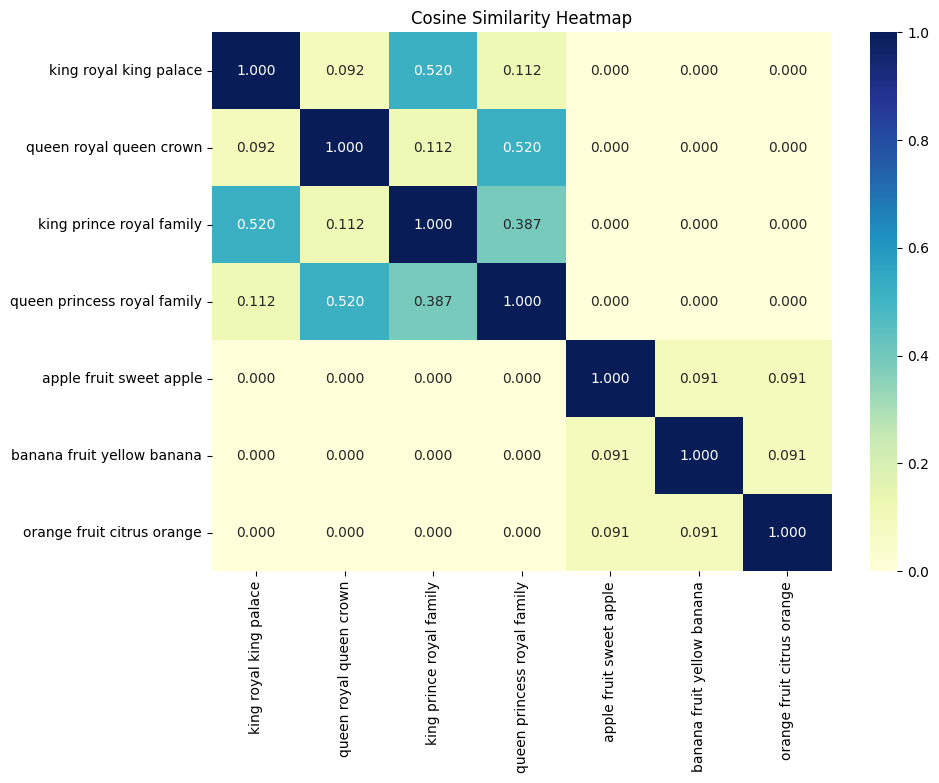

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import seaborn as sns
pd.set_option('display.float_format', '{:.5f}'.format)

# Sample words / small phrases
words = [
    "king royal king palace",
    "queen royal queen crown",
    "king prince royal family",
    "queen princess royal family",
    "apple fruit sweet apple",
    "banana fruit yellow banana",
    "orange fruit citrus orange"
]

# Convert words into vectors
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(words)

# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(X)

# Convert to DataFrame for better display
df = pd.DataFrame(similarity_matrix, index=words, columns=words)

# print("Cosine Similarity Matrix:\n")
# print(df)
plt.figure(figsize=(10,7))

sns.heatmap(df,
            annot=True,
            cmap="YlGnBu",
            fmt=".3f")

plt.title("Cosine Similarity Heatmap")

plt.show()

In [19]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.9 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/8.1 MB 1.9 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/8.1 MB 1.9 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/8.1 MB 1.9 MB/s eta 0:00:05
   --- -------------

In [24]:
pip install matplotlib.pyplot

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot
